# Code to make heatmaps using latent representations of data in LLMs!

In [1]:
## == CUSTOM HELPER FUNCTIONS == ##
import torch
import gc
import analysis_functions as topo
import heatmap_functions as ling

/Users/kimlopez/TDA_RI/TDA_reason-interpret/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## == DATASETS == ##
# [0]: hellaswag, [1]-[5]: mmlu
datasets = [["hellaswag", "~/TDA_RI/TDA_reason-interpret/datasets/hellaswag.csv"],
            ["mmlu_law", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_law.csv"],
            ["mmlu_math", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_math.csv"],
            ["mmlu_misc", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_misc.csv"],
            ["mmlu_moral", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_moral.csv"],
            ["mmlu_psych", "~/TDA_RI/TDA_reason-interpret/datasets/mmlu_psych.csv"]]

## == MODELS == ##
# [0]: Llama, [1]: Qwen, [2]: Mistral
models = [["Llama 3.1 8B", "meta-llama/Llama-3.1-8B", "llama"],
          ["Qwen 3 8B", "Qwen/Qwen3-8B", "qwen"],
          ["Mistral 7B v0.3", "mistralai/Mistral-7B-v0.3", "mistral"]]

+--------------------+--------------------+-----------------------+------------------------+-----------------------+--------------------+----------------------+
|       label        |      num_feat      |        max_feat       | max_feat_minus_second  |       mean_feat       |    betti_curve     | persistence_entropy  |
+--------------------+--------------------+-----------------------+------------------------+-----------------------+--------------------+----------------------+
|    correct_0dim    |       155.47       |   0.7894708251953125  |   0.0149969482421875   |   0.6874217757181639  | 133.27799999999996 |  4.9193159193438545  |
| correct_0dim_stdv  | 7.317330404076628  |  0.003068095999282179 | 0.0014892902285463254  | 0.0010022960821548734 | 6.086740100456487  | 0.052086012948188355 |
|    correct_1dim    |        0.0         |          0.0          |          0.0           |          0.0          |        0.0         |         0.0          |
|  correct_1dim_std  |        0.0 

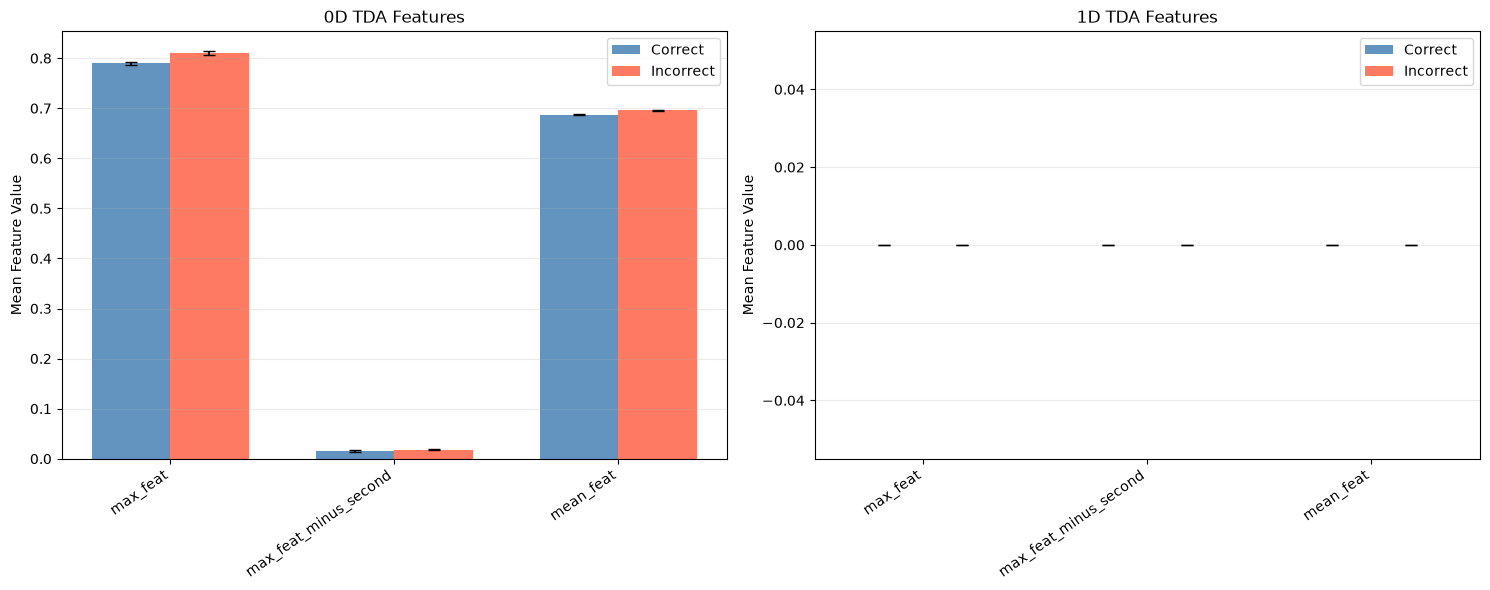

0

In [3]:
# prelim analysis
topo.analyze_feats(models[0], datasets[0], True)

In [4]:
# heatmap labels
linguistic_labels = [['Linguistic Features',["num_tokens", "num_types", "avg_word_length", "char_count",
                        "ttr", "cttr", "herdan_c", "simpson_div", "yules_k",
                        "num_content_words", "lexical_density",
                        "avg_polysemy", "num_long_words", "long_word_ratio", "hapax_legomena", "hapax_ratio",
                        "num_stopwords", "stopword_ratio",
                        "noun_ratio", "verb_ratio", "adj_ratio", "adv_ratio",
                        "entropy", "top_word_freq",
                        "unique_bigram_approx"]]
]

tda_labels = [["Topological Features", ['Num_0dim', 'Max_0dim', 'Max_0dim_Minus_Second', 'Mean_0dim', 'betti_curve_0', 'persistence_entropy_0', 'Num_1dim', 'Max_1dim', 'Max_1dim_Minus_Second', 'Mean_1dim', 'betti_curve_1', 'persistence_entropy_1']],
              ["h0 Features", ["Num_0dim", "Max_0dim", "Mean_0dim", "betti_curve_0", "persistence_entropy_0"]],
              ["h1 Features", ["Num_1dim", "Max_1dim", "Mean_1dim", "betti_curve_1", "persistence_entropy_1"]]
]

print("# features: ", len(linguistic_labels[0][1]))

# features:  25


Correct samples: 100
Incorrect samples: 100
Filtration range: 0.56835938 0.87652588


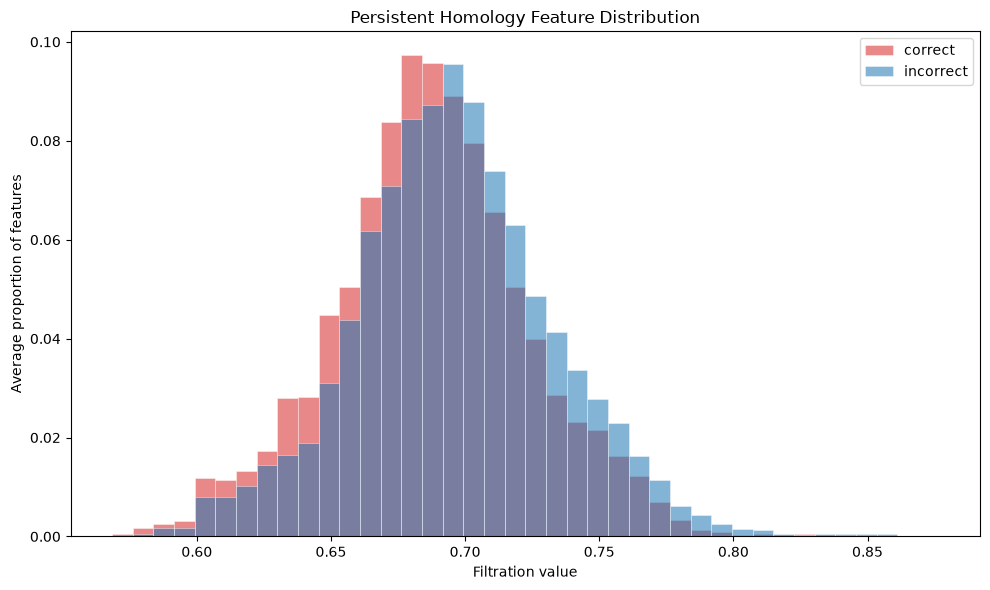

0

In [5]:
topo.plot_barcode(models[0], datasets[0])

In [28]:
# get heatmap!
ling.make_heatmap(datasets[0], models[0], linguistic_labels[0], tda_labels[0])

NameError: name 'get_top_feat' is not defined

In [ ]:
# test pval corr matrix
# choose model and dataset
model_index2 = [1, 2, 5, 6]
data_index2 = [1, 1, 4, 4]
# model_id =  models[8]
# dataset = datasets[3]

# choose linguistic labels :0
tda_label2 = tda_labels[0]

# get heatmap!
for i in range(0,4):
    cor_heat = make_heatmap(datasets[data_index2[i]], models[model_index2[i]], linguistic_labels[0], tda_label, extra_label = "_appendix", save = True)
    p_heat = make_pval_heatmap(datasets[data_index2[i]], models[model_index2[i]], linguistic_labels[0], tda_label, extra_label = "_appendix", save = True)


In [ ]:
per_sig, avg_pval = make_pval_heatmap(datasets[0], models[0])

# rows = ['Llama'] #, 'Qwen 3','RoBERTa', 'Electra']
# columns = ['flores-200'] #, 'OPUS-100']

# df_per = pd.DataFrame(per_sig)
# df_avg = pd.DataFrame(avg_pval)

# df_per.columns = columns
# df_avg.columns = columns

# df_per = df_per.mean(axis=1)
# df_avg = df_avg.mean(axis=1)

# print(df_per)
# print(df_avg)

In [ ]:
# code for table with avg number of words and sentences per data for appendix
for dataset in datasets:
    name, data_csv, eng_label, _ = data_label(dataset)
    df_dataset = pd.read_csv(data_csv)

    # count sentences and words
    df_dataset["sentence_count"] = df_dataset[f"{eng_label}"].apply(lambda x: len(sent_tokenize(x)))
    df_dataset["word_count"] = df_dataset[f"{eng_label}"].apply(lambda x: len(word_tokenize(x)))

    # compute averages
    avg_words = df_dataset["word_count"].mean()
    avg_sentences = df_dataset["sentence_count"].mean()

    print(name, ": ")
    summary_table = pd.DataFrame({
        "Metric": ["Average Words", "Average Sentences"],
        "Value": [avg_words, avg_sentences]
    })

    print(summary_table)